In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m

import sys
sys.path.insert(0, os.getcwd().removesuffix("/lane"))
from file_utils import readData, float2latex
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/lane/"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Aug2025/"

colors = ["darkorange", "olive", "orangered", "crimson", "#2544D0", "goldenrod", "k"]

Temperature statistics : nr, Max, Min, Avg, Std. dev. : 70 124.776 95.3964 107.8723 3.5785
Temperature statistics : nr, Max, Min, Avg, Std. dev. : 71 211.831 163.187 185.1737 5.8804
Temperature statistics : nr, Max, Min, Avg, Std. dev. : 72 344.685 279.192 307.8151 8.684


Text(0, 0.5, '$\\langle T_{kin}^* \\rangle$')

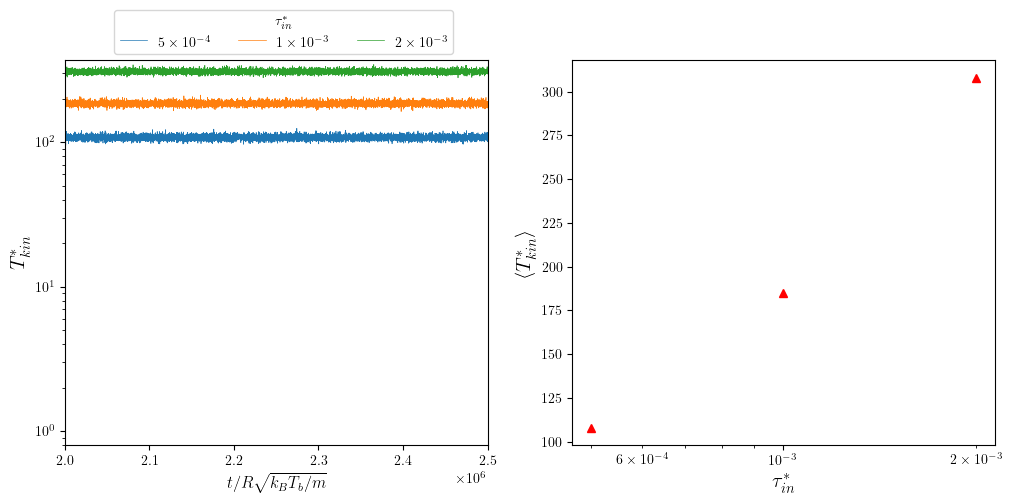

In [5]:
# Plot temperature vs time (v1)

nr_list = [70, 71, 72]
tau_list = ["5e-4", "1e-3", "2e-3", "5e-3", "1e-2", "2e-2", "5e-2", "1e-1", "2e-1", "5e-1", "1e0", "2e0"]
frame_list = [2000]
dt = [5e-4] + [5e-4]*(len(nr_list) - 1)

eq_steps = 1e7
interval = 1

fig1, ax1 = plt.subplots(1, 2, figsize = (12, 5))
for i in range(len(nr_list)):
    fpath = os.path.join(dirpath, "Data{nr}".format(nr = nr_list[i]), "temp.dat")

    [[step, T], _] = readData(fpath, 1)
    time = [(j - eq_steps)*dt[i] for j in step]

    avgT = sum(T)/len(T)
    var = [(j - avgT)**2 for j in T]
    var = sum(var)/(len(var) - 1)
    print("Temperature statistics : nr, Max, Min, Avg, Std. dev. : {nr} {Max} {Min} {Avg} {std}".format(nr = nr_list[i],
                                                                                                           Max = round(max(T), 4), 
                                                                                                           Min = round(min(T), 4), 
                                                                                                           Avg = round(avgT, 4), 
                                                                                                           std = round(np.sqrt(var), 4)))
    
    ax1[0].semilogy(time[0::interval], T[0::interval], lw = 0.5, label = r"${tau}$".format(tau = float2latex([tau_list[i]])))
    ax1[1].semilogx(liteval(tau_list[i]), avgT, "r^")
    
    # for j in frame_list:
    #     if(j < len(time)):
    #         ax1[0].plot(time[j], T[j], "ro", ms = 6)
        
ax1[0].set_xlim((2.0e6, 2.5e6))

ax1[0].set_ylim(bottom = 0.8)
ax1[0].set_xlabel(r"$t/R \sqrt{k_BT_b/m}$", fontsize = 12)
ax1[0].set_ylabel(r"$T_{kin}^*$", fontsize = 15)
ax1[0].legend(title = r"$\tau_{in}^*$", ncols = 3, bbox_to_anchor=(0.1, 1.0))
# ax1[0].set_title(r"$F_d^* = 90$", loc = "left")

# ax1[1].set_ylim(ylim = (0.9, 1.5))
ax1[1].set_xlabel(r"$\tau_{in}^*$", fontsize = 15)
ax1[1].set_ylabel(r"$\langle T_{kin}^* \rangle$", fontsize = 15)

# fig1.savefig(os.path.join(figpath, "temp_time_evolve_Fd90.png"), dpi = 500, bbox_inches = "tight")

Temperature statistics : tau, Max, Min, Avg, Std. dev. : 1e-3 1.1116 0.9006 1.0091 0.0277
Temperature statistics : tau, Max, Min, Avg, Std. dev. : 1e-2 2.2056 1.7975 1.9901 0.0548
Temperature statistics : tau, Max, Min, Avg, Std. dev. : 5e-2 26.606 16.1565 22.384 2.5888
Temperature statistics : tau, Max, Min, Avg, Std. dev. : 10e-2 61.4122 42.9457 50.4455 2.0953
Temperature statistics : tau, Max, Min, Avg, Std. dev. : 1e0 342.365 239.115 283.8117 12.2738


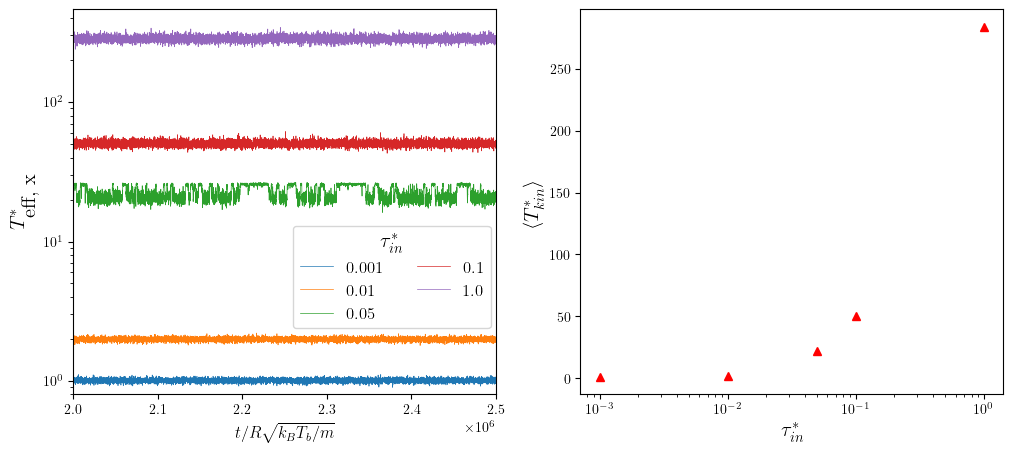

In [52]:
# Plot temperature vs time (v2)

tau_list = ["1e-3", "1e-2", "5e-2", "10e-2", "1e0"]
frame_list = [2000]
dt = [5e-4] + [5e-4]*(len(tau_list) - 1)

eq_steps = 1e7
interval = 1

fig1, ax1 = plt.subplots(1, 2, figsize = (12, 5))
for i in range(len(tau_list)):
    fpath = os.path.join(dirpath, "Aug2025", "Fd100", "tau_{nr}".format(nr = tau_list[i]), "temp.dat")

    [data, _] = readData(fpath, 1)
    step = data[0]
    T = data[2]
    
    time = [(j - eq_steps)*dt[i] for j in step]

    avgT = sum(T)/len(T)
    var = [(j - avgT)**2 for j in T]
    var = sum(var)/(len(var) - 1)
    print("Temperature statistics : tau, Max, Min, Avg, Std. dev. : {tau} {Max} {Min} {Avg} {std}".format(tau = tau_list[i],
                                                                                                           Max = round(max(T), 4), 
                                                                                                           Min = round(min(T), 4), 
                                                                                                           Avg = round(avgT, 4), 
                                                                                                           std = round(np.sqrt(var), 4)))
    
    ax1[0].semilogy(time[0::interval], T[0::interval], lw = 0.5, label = r"${tau}$".format(tau = liteval(tau_list[i])))
    ax1[1].semilogx(liteval(tau_list[i]), avgT, "r^")
    
    # for j in frame_list:
    #     if(j < len(time)):
    #         ax1[0].plot(time[j], T[j], "ro", ms = 6)
        
ax1[0].set_xlim((2.0e6, 2.5e6))

ax1[0].set_ylim(bottom = 0.8)
ax1[0].set_xlabel(r"$t/R \sqrt{k_BT_b/m}$", fontsize = 12)
ax1[0].set_ylabel(r"$T_{\textrm{eff, x}}^*$", fontsize = 15)
leg = ax1[0].legend(title = r"$\tau_{in}^*$", ncols = 2, fontsize = 12, bbox_to_anchor=(0.5, 0.15))
leg.get_title().set_fontsize("15")

# ax1[1].set_ylim(ylim = (0.9, 1.5))
ax1[1].set_xlabel(r"$\tau_{in}^*$", fontsize = 15)
ax1[1].set_ylabel(r"$\langle T_{kin}^* \rangle$", fontsize = 15)

# fig1.savefig(os.path.join(figpath, "Temp_x_time_evolve_Fd100.png"), dpi = 500, bbox_inches = "tight")

In [8]:
# Compute thermal velocities by subtracting centre-of-mass velocity for the system as a whole

fpath = os.path.join(dirpath, "Data{nr}".format(nr = 43), "velocities_frame49431.dat")

[data,_] = readData(fpath, 1)

id = data[0]
type = data[1]
rx = data[2]
ry = data[3]
vx = data[4]
vy = data[5]

N = len(id)
print(N)

print(max(vx), min(vx))
print(max(vy), min(vy))

vCom = [0.0, 0.0]

for i in range(len(id)):
    vCom[0] += vx[i]
    vCom[1] += vy[i]

vCom = [(i/N) for i in vCom]

print(vCom)

vxth = np.zeros(len(id))
vyth = np.zeros(len(id))

for i in range(len(id)):
    vxth[i] = vx[i] - vCom[0]
    vyth[i] = vy[i] - vCom[1]

FileNotFoundError: [Errno 2] No such file or directory: '//media/ashwin/Expansion/ashwin_md/lane/Data43/velocities_frame49431.dat'

In [ ]:
# Plot the distribution of velocities

binW = 4.0
min_v = -100
max_v = 100

nBins = int((max_v - min_v)/binW)
Pvx = np.zeros(nBins)
Pvy = np.zeros(nBins)
Pvxth = np.zeros(nBins)
Pvyth = np.zeros(nBins)
Bins = np.linspace(min_v, max_v, nBins)

for i in range(len(id)):
    Pvx[int((vx[i] + max_v)/binW)] += 1
    Pvy[int((vy[i] + max_v)/binW)] += 1
    Pvxth[int((vxth[i] + max_v)/binW)] += 1
    Pvyth[int((vyth[i] + max_v)/binW)] += 1

Pvx = [i/(len(id)*binW) for i in Pvx]
Pvy = [i/(len(id)*binW) for i in Pvy]
Pvxth = [i/(len(id)*binW) for i in Pvxth]
Pvyth = [i/(len(id)*binW) for i in Pvyth]
Pv_boltz = [np.exp(-0.5*v*v)/m.sqrt(2*m.pi) for v in Bins]

sig = 2
Pv_gauss = [np.exp(-0.5*(v/sig)**2)/m.sqrt(2*m.pi*sig**2) for v in Bins]

fig, ax = plt.subplots(2, 1, figsize = (5, 10))
ax[0].plot(Bins, Pvx, "k-", label = r"$v_x$")
ax[0].plot(Bins, Pvy, "ko", label = r"$v_y$")
ax[1].plot(Bins, Pvxth, "r-", label = r"$v_x^{th}$")
ax[1].plot(Bins, Pvyth, "ro", label = r"$v_y^{th}$")
ax[0].plot(Bins, Pv_boltz, "b--", label = "MB dist.")
ax[1].plot(Bins, Pv_boltz, "b--", label = "MB dist.")

ax[0].set(xlim = (min_v, max_v))
ax[0].set_xlabel(r"$v_{\alpha}^{kin}$", fontsize = 12)
ax[0].set_ylabel(r"$P(v_{\alpha}^{kin})$", fontsize = 12)
ax[0].legend(fontsize = 12)

ax[1].set(xlim = (min_v, max_v))
ax[1].set_xlabel(r"$v_{\alpha}^{th}$", fontsize = 12)
ax[1].set_ylabel(r"$P(v_{\alpha}^{th})$", fontsize = 12)
ax[1].legend(fontsize = 12)

print(Bins)

# fig.savefig(os.path.join(figpath, "nr48_gamma_2e-1_vel_dist.png"), dpi = 600, bbox_inches = "tight")

In [ ]:
# Thermal plots

Lx = 150
Ly = 30
ms = 2.4

cmap1 = mpl.colormaps['rainbow']

def return_color(val, max_val):
    color = cmap1(val/max_val)
    return(color)

T_kin = [0.5*(vx[i]*vx[i] + vy[i]*vy[i]) for i in range(len(id))]
T_th = [0.5*(vxth[i]*vxth[i] + vyth[i]*vyth[i]) for i in range(len(id))]
max_T_kin = max(T_kin)
max_T_th = max(T_th)
print(max_T_kin, max_T_th)

fig, ax = plt.subplots(2, 1, figsize = (10, 4))

for i in range(len(id)):
    ax[0].plot(rx[i], ry[i], "o", color = return_color(T_kin[i], max_T_kin), ms = ms)
    ax[1].plot(rx[i], ry[i], "o", color = return_color(T_th[i], max_T_th), ms = ms)
    
for i in range(len(ax)):
    ax[i].set(xlim = (0, Lx), ylim = (0, Ly))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

ax[0].set_ylabel(r"$T^*_{kin} = {val}$".format(kin = "{kin}", val = TempKin), fontsize = 14)
ax[1].set_ylabel(r"$T^*_{th} = {val}$".format(th = "{th}", val = TempTh), fontsize = 14)

clb = mpl.cm.ScalarMappable(norm = mpl.colors.Normalize(0, max_T_kin), cmap = "rainbow")
cbar = fig.colorbar(clb, ax = ax[:], location = "right", shrink = 1.0, aspect = 20, pad = 0.02, fraction = 0.08)
cbar.set_label(label = r"$\tau^*$", fontsize = 15)

fig.savefig(os.path.join(figpath, "nr48_gamma_2e-1_therm_plot.png"), dpi = 500, bbox_inches = "tight")

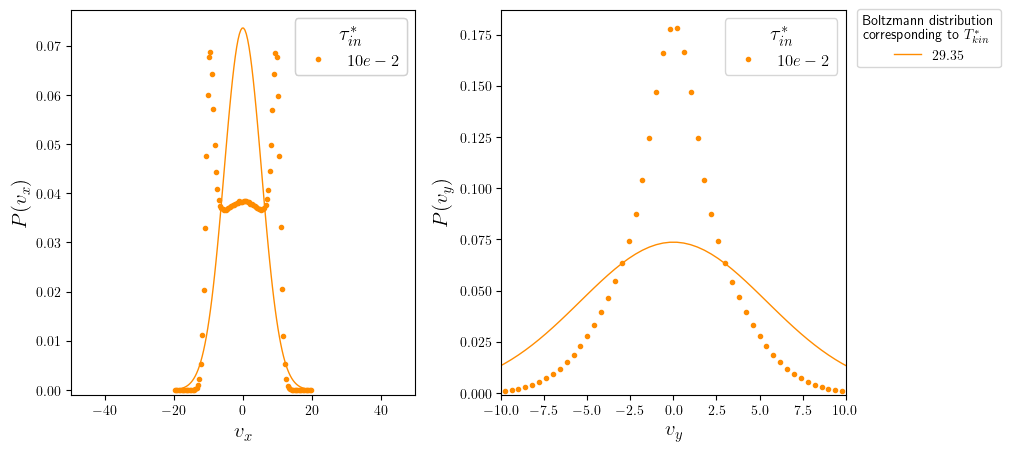

In [7]:
# Plot the time-averaged velocity distribution

tau_list = ["10e-2"]

fpath = os.path.join(dirpath, "Aug2025", "Fd100", "avgTemp.dat")
[data, _] = readData(fpath)

nr = data[0]
tau = data[1]
temp = data[4]

Tkin = []

for i in range(len(tau_list)):
    index = tau.index(liteval(tau_list[i]))
    Tkin.append(round(temp[index], 2))

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ms = 3
lw = 1
points = [[], []]
lines = [[], []]

for i in range(len(tau_list)):

    fpath = os.path.join(dirpath, "Aug2025", "Fd100", "tau_{tau}".format(tau = tau_list[i]), "velocityDist.dat")
    [[bin, Pvx, Pvy], fields] = readData(fpath, 1)
    
    nBins = len(bin)
    vxmax = fields[2]
    vymax = fields[4]
    vxbinW = fields[6]
    vybinW = fields[8]
    
    vx = [(-vxmax + vxbinW * (i + 0.5)) for i in range(nBins)]
    vy = [(-vymax + vybinW * (i + 0.5)) for i in range(nBins)]

    Pvx_boltz = [(m.exp(-v*v/(2*Tkin[i]))/m.sqrt(2*m.pi*Tkin[i])) for v in vx]
    Pvy_boltz = [(m.exp(-v*v/(2*Tkin[i]))/m.sqrt(2*m.pi*Tkin[i])) for v in vy]

    line1, = ax[0].plot(vx, Pvx_boltz, "-", lw = lw, color = colors[i], label = r"${temp}$".format(temp = Tkin[i]))
    line2, = ax[1].plot(vy, Pvy_boltz, "-", lw = lw, color = colors[i], label = r"${temp}$".format(temp = Tkin[i]))
    lines[0].append(line1)
    lines[1].append(line2)
    
    point1, = ax[0].plot(vx, Pvx, "o", ms = ms, color = colors[i], label = r"${tau}$".format(tau = tau_list[i]))
    point2, = ax[1].plot(vy, Pvy, "o", ms = ms, color = colors[i], label = r"${tau}$".format(tau = tau_list[i]))
    points[0].append(point1)
    points[1].append(point2)

ax[0].set_xlabel(r"$v_x$", fontsize = 15)
ax[0].set_ylabel(r"$P(v_x)$", fontsize = 15)
leg1 = ax[0].legend(handles = points[0], title = r"$\tau_{in}^*$", fontsize = 12)
leg1.get_title().set_fontsize("15")
leg1A = plt.legend(handles = lines[0], bbox_to_anchor = (1, 0))
ax[0].add_artist(leg1)

ax[1].set_xlabel(r"$v_y$", fontsize = 15)
ax[1].set_ylabel(r"$P(v_y)$", fontsize = 15)
leg2 = ax[1].legend(handles = points[1], title = r"$\tau_{in}^*$", fontsize = 12)
leg2.get_title().set_fontsize("15")
leg2A = plt.legend(handles = lines[1], bbox_to_anchor = (1.47, 1.02), title = "Boltzmann distribution \ncorresponding to $T_{kin}^*$")
ax[1].add_artist(leg2)

ax[0].set(xlim = (-50, 50))
ax[1].set(xlim = (-10, 10))
ax[0].set_ylim(bottom = -1e-3)
ax[1].set_ylim(bottom = -1e-3)

plt.subplots_adjust(wspace = 0.25)

# fig.savefig(os.path.join(figpath, "velocityDist_Pe90_1.png"), dpi = 500, bbox_inches = "tight")

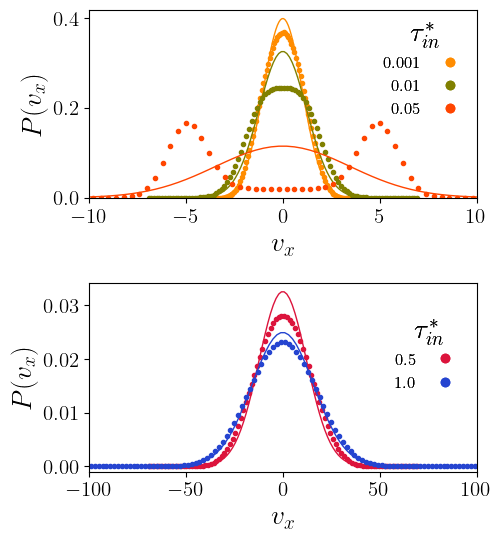

In [31]:
# Plot the time-averaged velocity distribution

tau_list = ["1e-3", "1e-2", "5e-2", "5e-1", "1e0"]

fpath = os.path.join(dirpath, "Aug2025", "Fd100", "avgTemp.dat")
[data, _] = readData(fpath)

tau = data[1]
temp = data[4]

Tkin = []

for i in range(len(tau_list)):
    index = tau.index(liteval(tau_list[i]))
    Tkin.append(round(temp[index], 2))

fig, ax = plt.subplots(2, 1, figsize = (5, 6))
ms = 3
lw = 1

points = []
lines = []
for i in range(0, 3):
    
    fpath = os.path.join(dirpath, "Aug2025", "Fd100", "tau_{tau}".format(tau = tau_list[i]), "velocityDist.dat")
    [[bin, Pvx, Pvy], fields] = readData(fpath, 1)
    
    nBins = len(bin)
    vxmax = fields[2]
    vxbinW = fields[6]
    
    vx = [(-vxmax + vxbinW * (i + 0.5)) for i in range(nBins)]
    Pvx_boltz = [(m.exp(-v*v/(2*Tkin[i]))/m.sqrt(2*m.pi*Tkin[i])) for v in vx]

    line1, = ax[0].plot(vx, Pvx_boltz, "-", lw = lw, color = colors[i], label = r"${temp}$".format(temp = Tkin[i]))
    lines.append(line1)
    
    point1, = ax[0].plot(vx, Pvx, "o", ms = ms, color = colors[i], label = r"${tau}$".format(tau = liteval(tau_list[i])))
    points.append(point1)

ax[0].set_xlabel(r"$v_x$", fontsize = 20)
ax[0].set_ylabel(r"$P(v_x)$", fontsize = 20)
leg1 = ax[0].legend(handles = points, title = r"$\tau_{in}^*$", markerscale = 2, ncols = 1, frameon = False, fontsize = 12, 
                    bbox_to_anchor = (0.72, 0.35), markerfirst = False)
leg1.get_title().set_fontsize("20")
leg1A = plt.legend(handles = lines, bbox_to_anchor = (1, 0))
ax[0].add_artist(leg1)
ax[0].tick_params(axis='both', which='major', labelsize = 15)

points = []
for i in range(3, 5):
    
    fpath = os.path.join(dirpath, "Aug2025", "Fd100", "tau_{tau}".format(tau = tau_list[i]), "velocityDist.dat")
    [[bin, Pvx, Pvy], fields] = readData(fpath, 1)
    
    nBins = len(bin)
    vxmax = fields[2]
    vxbinW = fields[6]
    
    vx = [(-vxmax + vxbinW * (i + 0.5)) for i in range(nBins)]
    Pvx_boltz = [(m.exp(-v*v/(2*Tkin[i]))/m.sqrt(2*m.pi*Tkin[i])) for v in vx]

    line1, = ax[1].plot(vx, Pvx_boltz, "-", lw = lw, color = colors[i], label = r"${temp}$".format(temp = Tkin[i]))
    lines.append(line1)
    
    point1, = ax[1].plot(vx, Pvx, "o", ms = ms, color = colors[i], label = r"${tau}$".format(tau = liteval(tau_list[i])))
    points.append(point1)

ax[1].set_xlabel(r"$v_x$", fontsize = 20)
ax[1].set_ylabel(r"$P(v_x)$", fontsize = 20)
leg2 = ax[1].legend(handles = points, title = r"$\tau_{in}^*$", markerscale = 2, ncols = 1, frameon = False, fontsize = 12, 
                    bbox_to_anchor = (0.75, 0.35), markerfirst = False)
leg2.get_title().set_fontsize("20")

ax[1].add_artist(leg2)
ax[1].tick_params(axis='both', which='major', labelsize = 15)

ax[0].set(xlim = (-10, 10))
ax[1].set(xlim = (-100, 100))
ax[0].set_ylim(bottom = -1e-3)
ax[1].set_ylim(bottom = -1e-3)

plt.subplots_adjust(hspace = 0.45, wspace = 0.3)

# fig.savefig(os.path.join(figpath, "velocityDist_Fd100.png"), dpi = 500, bbox_inches = "tight")